## Description - Figure 5
Now that we know what factors can affect nfl
so we could start to build the final model 
race, smoking, lytics  affects log_nfl, ct_factor, basline il10, and delta_csf affects log_nfl
Now we can rigorously evaluate taVNS effect.



best power for the base model is 0.65
best power for the final model is 0.5

--- BASE MODEL SUMMARY ---

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_nfl  
No. Observations: 121     Method:             ML       
No. Groups:       35      Scale:              0.3446   
Min. group size:  1       Log-Likelihood:     -145.9949
Max. group size:  4       Converged:          Yes      
Mean group size:  3.5                                  
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     3.027    0.180 16.803 0.000  2.674  3.380
time_pow_base 0.747    0.053 14.116 0.000  0.643  0.851
Group Var     0.841    0.454                           


--- FINAL MODEL SUMMARY ---

                Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      log_nfl  
No. Observations:   

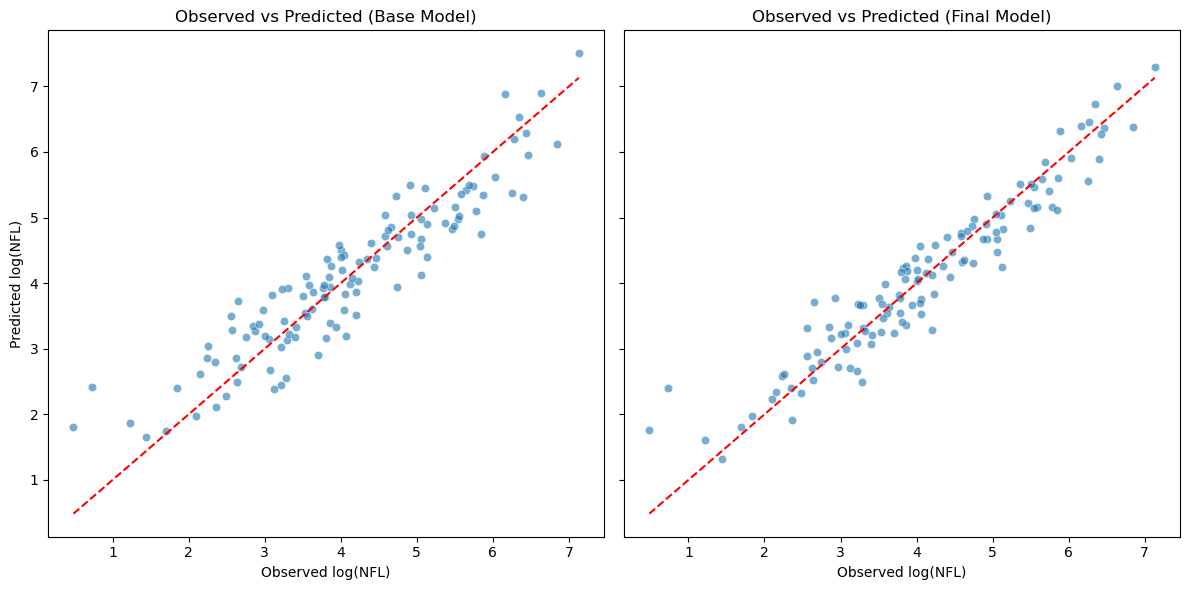

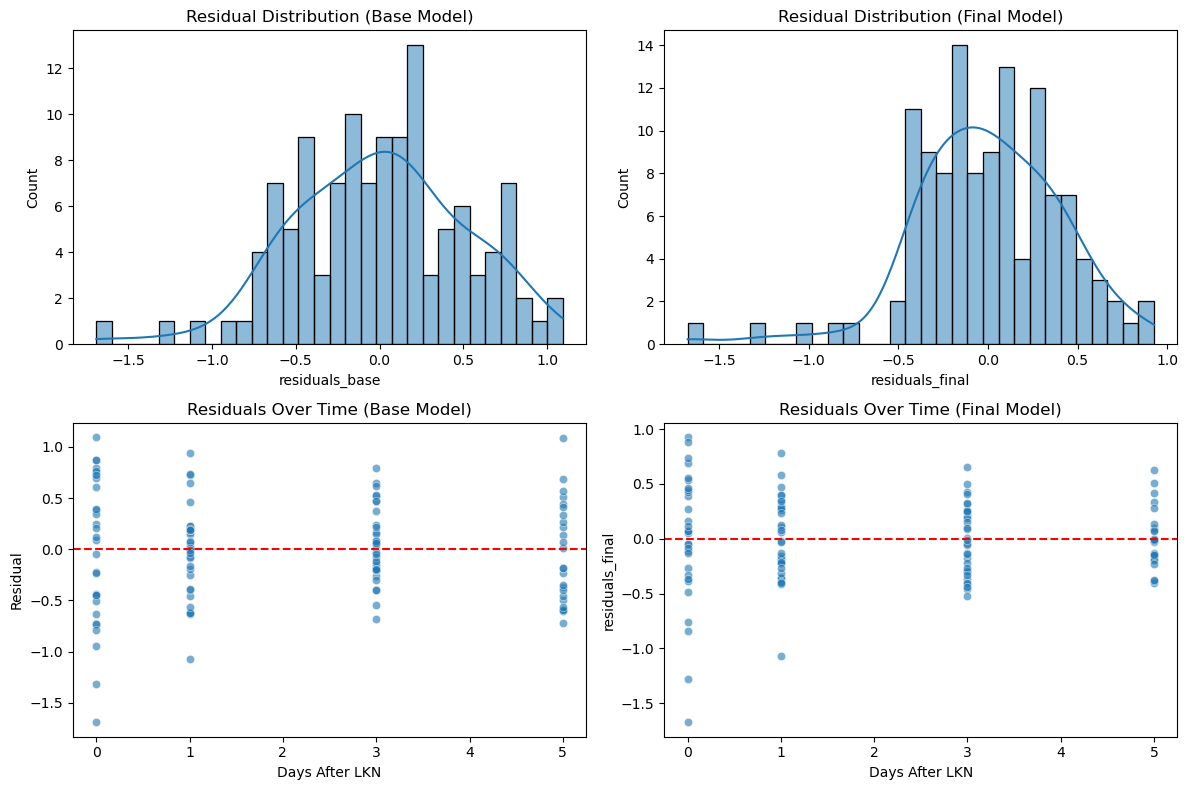


=== Model Fit Comparison ===

                    AIC         BIC      logLik       MSE        R2
Base Model   299.989707  311.172869 -145.994854  0.256214  0.858229
Final Model  258.254051  286.211957 -119.127026  0.165423  0.908466
                     AIC         BIC      logLik       MSE      RMSE  \
Base Model    299.989707  311.172869 -145.994854  0.256214  0.506175   
Final Model   258.254051  286.211957 -119.127026  0.165423  0.406723   
Final − Base  -41.735656  -24.960912   26.867828 -0.090790 -0.099453   

                   MAE        SSE      n  
Base Model    0.403433  31.001837  121.0  
Final Model   0.310610  20.016237  121.0  
Final − Base -0.092823 -10.985600    0.0  
LR_statistic    5.373566e+01
df              6.000000e+00
p_value         8.340378e-10
dtype: float64
             R2_marginal  R2_conditional
Base Model      0.337810        0.807479
Final Model     0.606305        0.883716


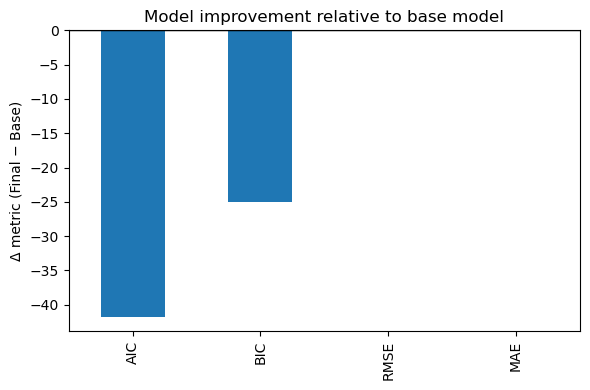

In [1]:
# Do final model - time varying
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import chi2
imputed_nfl_df = pd.read_csv('nihss_nfl_cyto_mrs_wbc_mrs_imputedct.csv',
    index_col=0
)

nfl_plot_data = (
    imputed_nfl_df[imputed_nfl_df['days_after_lkn'].isin([0,1,3,5])]
    .dropna(subset=['nfl'])
    .drop_duplicates(subset=['personid','days_after_lkn','nfl'])
    .copy()
)
nfl_plot_data['smoking_binary'] = nfl_plot_data['smoking'].map({0: 0, 1: 1, 2: 1})

nfl_plot_data['log_nfl'] = np.log(nfl_plot_data['nfl'])
cont_models = pd.read_csv("nfl_continuous_models.csv")
cont_corr_df_all = pd.read_csv("nfl_continuous_correlations.csv")

imputed_cont_models = pd.read_csv("imputed_nfl_continuous_models.csv")
imputed_cont_corr_df_all = pd.read_csv("imputed_nfl_continuous_correlations.csv")
cont_models["source"] = "original"
imputed_cont_models["source"] = "imputed"

cont_corr_df_all["source"] = "original"
imputed_cont_corr_df_all["source"] = "imputed"
all_cols_models = list(set(cont_models.columns) | set(imputed_cont_models.columns))
cont_models = cont_models.reindex(columns=all_cols_models)
imputed_cont_models = imputed_cont_models.reindex(columns=all_cols_models)

all_cols_corr = list(set(cont_corr_df_all.columns) | set(imputed_cont_corr_df_all.columns))
cont_corr_df_all = cont_corr_df_all.reindex(columns=all_cols_corr)
imputed_cont_corr_df_all = imputed_cont_corr_df_all.reindex(columns=all_cols_corr)
merged_cont_models = pd.concat([cont_models, imputed_cont_models], ignore_index=True)
merged_cont_corr = pd.concat([cont_corr_df_all, imputed_cont_corr_df_all], ignore_index=True)

cont_models = merged_cont_models
cont_corr_df_all = merged_cont_corr

#  categorical data 
categorical_models = pd.read_csv("nfl_categorical_models.csv")
categorical_corr_df_all = pd.read_csv("nfl_categorical_effects.csv")



covariates = [
    "race", "smoking_binary", "lytics",
    "ct_factor_1_imp", "baseline_il10", 'delta_csf_ratio'
]
cat_vars = ["race", "smoking_binary", "lytics"]
cont_vars = ["ct_factor_1_imp", "baseline_il10", 'delta_csf_ratio']


nfl_plot_data['delta_csf_ratio'] = nfl_plot_data.groupby('days_after_lkn')['delta_csf_ratio'].transform(
    lambda x: x.fillna(x.median())
)

for cov in covariates:

    # get model mode decision
    if cov in cat_vars:
        mode_row = categorical_models[(categorical_models['categorical_var']==cov) & (categorical_models['response']=='log_nfl')]
        mode = mode_row["decision_mode"].values[0]
    else:
        mode_row = cont_models[(cont_models['predictor']==cov) & (cont_models['response']=='log_nfl')]
        mode = mode_row["mode"].values[0]

    if mode == "exclude":
        continue


    elif mode == "linear":
        nfl_plot_data[cov + "_transformed"] = nfl_plot_data[cov]

    elif mode == "gaussian":
        mu = float(mode_row["gauss_mu"].values[0])
        sigma = float(mode_row["gauss_sigma"].values[0])
        nfl_plot_data[cov + "_transformed"] = nfl_plot_data[cov] * np.exp(-((nfl_plot_data["days_after_lkn"] - mu)**2)/(2*sigma**2))

final_covariates = [c for c in nfl_plot_data.columns if c.endswith("_transformed")]

powers = np.linspace(0.3, 1.8, 31)
best_power_base, best_aic_base = None, np.inf

for p in powers:
    nfl_plot_data["time_pow_tmp"] = nfl_plot_data["days_after_lkn"] ** p
    try:
        base_m = smf.mixedlm("log_nfl ~ time_pow_tmp", nfl_plot_data, 
                             groups=nfl_plot_data["personid"], re_formula="1").fit(
            method="powell", reml=False, disp=False
        )
        if base_m.aic < best_aic_base:
            best_power_base, best_aic_base = float(p), base_m.aic
    except:
        print('base model fitting fails')
        continue

nfl_plot_data["time_pow_base"] = nfl_plot_data["days_after_lkn"] ** best_power_base

base_model = smf.mixedlm("log_nfl ~ time_pow_base", nfl_plot_data, 
                         groups=nfl_plot_data["personid"], re_formula="1").fit(
    method="powell", reml=False, disp=False
)
print(f'best power for the base model is {best_power_base}')
powers = np.linspace(0.3, 1.8, 31)
best_power, best_aic = None, np.inf

for p in powers:
    nfl_plot_data["time_pow_tmp"] = nfl_plot_data["days_after_lkn"] ** p
    formula = "log_nfl ~ time_pow_tmp + " + " + ".join(final_covariates)
    try:
        m = smf.mixedlm(formula, nfl_plot_data, groups=nfl_plot_data["personid"], re_formula="1").fit(
            method="powell", reml=False, disp=False
        )
        if m.aic < best_aic:
            best_power, best_aic = float(p), m.aic
    except:
        print('base model fitting fails')
        continue
print(f'best power for the final model is {best_power}')

nfl_plot_data["time_pow"] = nfl_plot_data["days_after_lkn"] ** best_power
final_formula = "log_nfl ~ time_pow + " + " + ".join(final_covariates)

final_model = smf.mixedlm(final_formula, nfl_plot_data, groups=nfl_plot_data["personid"], re_formula="1").fit(
    method="powell", reml=False, disp=False
)
def model_stats(model, df, yvar="log_nfl"):
    y = df[yvar]
    yhat = model.fittedvalues
    resid = y - yhat
    mse = np.mean(resid**2)
    r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
    return pd.Series({
        "AIC": model.aic,
        "BIC": model.bic,
        "logLik": model.llf,
        "MSE": mse,
        "R2": r2
    })

base_stats = model_stats(base_model, nfl_plot_data, "log_nfl")
final_stats = model_stats(final_model, nfl_plot_data, "log_nfl")

comparison_df = pd.DataFrame([base_stats, final_stats], index=["Base Model", "Final Model"])
comparison_df

print("\n--- BASE MODEL SUMMARY ---\n")
print(base_model.summary())

print("\n--- FINAL MODEL SUMMARY ---\n")
print(final_model.summary())

# ---------- Extract effect sizes ----------
effects = []
sd_y = nfl_plot_data["log_nfl"].std(ddof=1)

for cov in final_covariates:
    beta = final_model.fe_params.get(cov, np.nan)
    p_val = final_model.pvalues.get(cov, np.nan)
    sd_x = nfl_plot_data[cov].std(ddof=1)
    std_beta = beta * (sd_x / sd_y) if sd_x > 0 else np.nan
    effects.append((cov, beta, std_beta, p_val))

effects_df = pd.DataFrame(effects, columns=["covariate", "beta", "std_beta", "p_value"])
from statsmodels.stats.multitest import multipletests

# Number of tests = number of fixed-effect covariates
m = effects_df["p_value"].notna().sum()

# Apply Bonferroni
reject, p_bonf, _, _ = multipletests(effects_df["p_value"], 
                                     alpha=0.05, 
                                     method="bonferroni")

effects_df["p_bonf"] = p_bonf
effects_df["significant_bonf"] = reject
# pd.set_option("display.float_format", "{:.4g}".format)

print("\n=== Final Model Effects (Bonferroni Corrected) ===\n")
print(
    effects_df
    .sort_values("p_value")
    .reset_index(drop=True)
)


nfl_plot_data["predicted_base"] = base_model.fittedvalues
nfl_plot_data["predicted_final"] = final_model.fittedvalues
fig, axes = plt.subplots(1, 2, figsize=(12,6), sharex=True, sharey=True)

# Base model
sns.scatterplot(x="log_nfl", y="predicted_base", data=nfl_plot_data, alpha=0.6, ax=axes[0])
axes[0].plot([nfl_plot_data["log_nfl"].min(), nfl_plot_data["log_nfl"].max()],
             [nfl_plot_data["log_nfl"].min(), nfl_plot_data["log_nfl"].max()],
             linestyle="--", color="red")
axes[0].set_title("Observed vs Predicted (Base Model)")
axes[0].set_xlabel("Observed log(NFL)")
axes[0].set_ylabel("Predicted log(NFL)")

# Final model
sns.scatterplot(x="log_nfl", y="predicted_final", data=nfl_plot_data, alpha=0.6, ax=axes[1])
axes[1].plot([nfl_plot_data["log_nfl"].min(), nfl_plot_data["log_nfl"].max()],
             [nfl_plot_data["log_nfl"].min(), nfl_plot_data["log_nfl"].max()],
             linestyle="--", color="red")
axes[1].set_title("Observed vs Predicted (Final Model)")
axes[1].set_xlabel("Observed log(NFL)")
plt.tight_layout()

plt.show()


nfl_plot_data["residuals_base"] = nfl_plot_data["log_nfl"] - nfl_plot_data["predicted_base"]
nfl_plot_data["residuals_final"] = nfl_plot_data["log_nfl"] - nfl_plot_data["predicted_final"]

fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.histplot(nfl_plot_data["residuals_base"], kde=True, bins=30, ax=axes[0,0])
axes[0,0].set_title("Residual Distribution (Base Model)")

sns.histplot(nfl_plot_data["residuals_final"], kde=True, bins=30, ax=axes[0,1])
axes[0,1].set_title("Residual Distribution (Final Model)")

sns.scatterplot(x="days_after_lkn", y="residuals_base", data=nfl_plot_data, alpha=0.6, ax=axes[1,0])
axes[1,0].axhline(0, linestyle="--", color="red")
axes[1,0].set_title("Residuals Over Time (Base Model)")
axes[1,0].set_xlabel("Days After LKN")
axes[1,0].set_ylabel("Residual")

sns.scatterplot(x="days_after_lkn", y="residuals_final", data=nfl_plot_data, alpha=0.6, ax=axes[1,1])
axes[1,1].axhline(0, linestyle="--", color="red")
axes[1,1].set_title("Residuals Over Time (Final Model)")
axes[1,1].set_xlabel("Days After LKN")

plt.tight_layout()

plt.show()


print("\n=== Model Fit Comparison ===\n")
print(comparison_df)

# more eval
def model_stats_extended(model, df, yvar="log_nfl"):
    y = df[yvar].values
    yhat = model.fittedvalues.values
    resid = y - yhat

    return pd.Series({
        "AIC": model.aic,
        "BIC": model.bic,
        "logLik": model.llf,
        "MSE": np.mean(resid**2),
        "RMSE": np.sqrt(np.mean(resid**2)),
        "MAE": np.mean(np.abs(resid)),
        "SSE": np.sum(resid**2),
        "n": len(y)
    })
base_stats  = model_stats_extended(base_model, nfl_plot_data)
final_stats = model_stats_extended(final_model, nfl_plot_data)

comparison_df = pd.DataFrame(
    [base_stats, final_stats],
    index=["Base Model", "Final Model"]
)

# Improvement columns (Final – Base)
delta_df = (final_stats - base_stats).to_frame().T
delta_df.index = ["Final − Base"]

comparison_table = pd.concat([comparison_df, delta_df], axis=0)
print(comparison_table)


lr_stat = 2 * (final_model.llf - base_model.llf)
df_diff = final_model.df_modelwc - base_model.df_modelwc
lr_pval = chi2.sf(lr_stat, df_diff)

lr_test = pd.Series({
    "LR_statistic": lr_stat,
    "df": df_diff,
    "p_value": lr_pval
})

print(lr_test)
def mixedlm_r2(model, df, yvar="log_nfl"):
    """
    Approximate marginal and conditional R^2 for statsmodels MixedLM.
    """
    # Fixed effects prediction
    X = model.model.exog
    beta = model.fe_params.values
    fitted_fixed = X @ beta

    # Random effects variance
    var_random = float(model.cov_re.iloc[0, 0])
    var_resid  = model.scale  # residual variance

    # Variance of fixed effects
    var_fixed = np.var(fitted_fixed, ddof=1)

    r2_marginal = var_fixed / (var_fixed + var_random + var_resid)
    r2_conditional = (var_fixed + var_random) / (var_fixed + var_random + var_resid)

    return pd.Series({
        "R2_marginal": r2_marginal,
        "R2_conditional": r2_conditional
    })
r2_base  = mixedlm_r2(base_model, nfl_plot_data)
r2_final = mixedlm_r2(final_model, nfl_plot_data)

r2_df = pd.DataFrame(
    [r2_base, r2_final],
    index=["Base Model", "Final Model"]
)

print(r2_df)
metrics_to_plot = ["AIC", "BIC", "RMSE", "MAE"]
improvement = comparison_df.loc["Final Model", metrics_to_plot] - \
              comparison_df.loc["Base Model", metrics_to_plot]

plt.figure(figsize=(6,4))
improvement.plot(kind="bar")
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Δ metric (Final − Base)")
plt.title("Model improvement relative to base model")
# plt.ylim([-40, 1])
plt.tight_layout()
plt.show()

# bonferroni- correction


## NfL by treatment and stroke volume

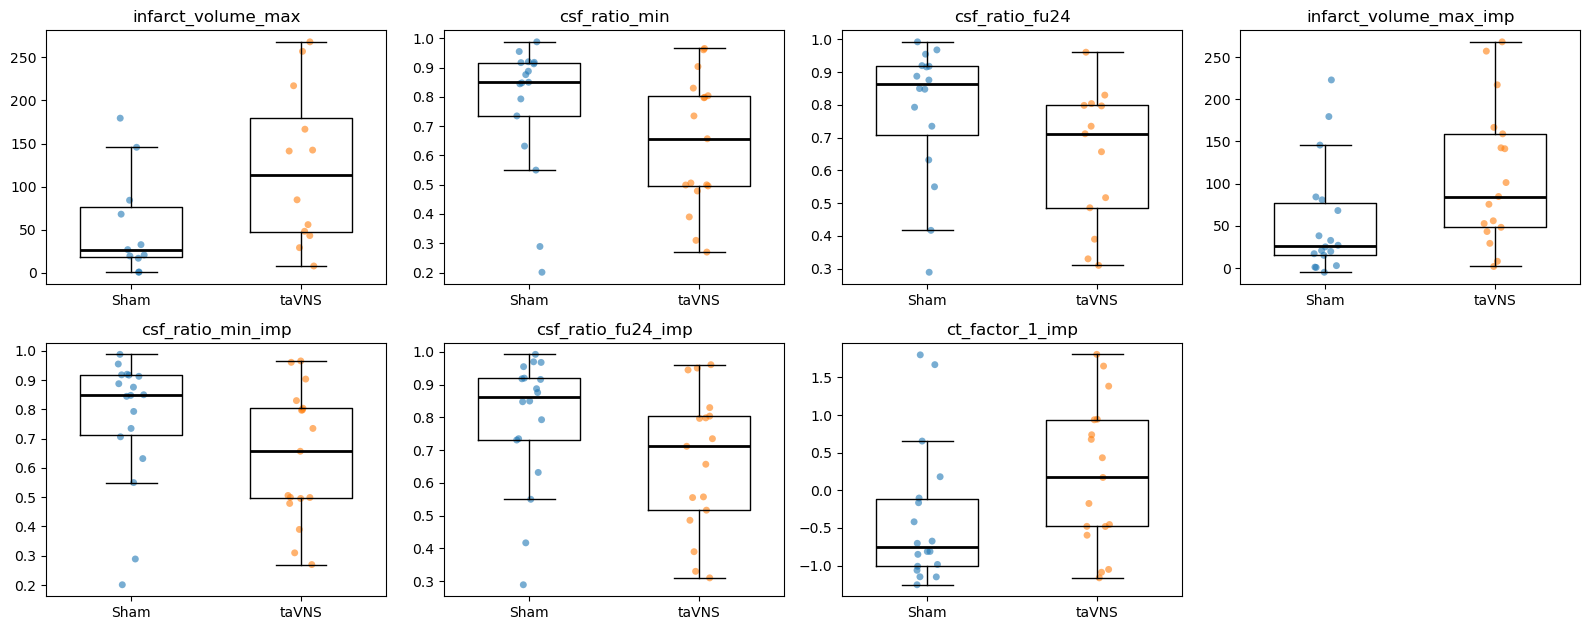

/var/folders/6r/pj2ql3m51fv8_ycglzy0hnh40000gn/T/ipykernel_51298/2896104612.py:151: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  sc = ax.scatter(


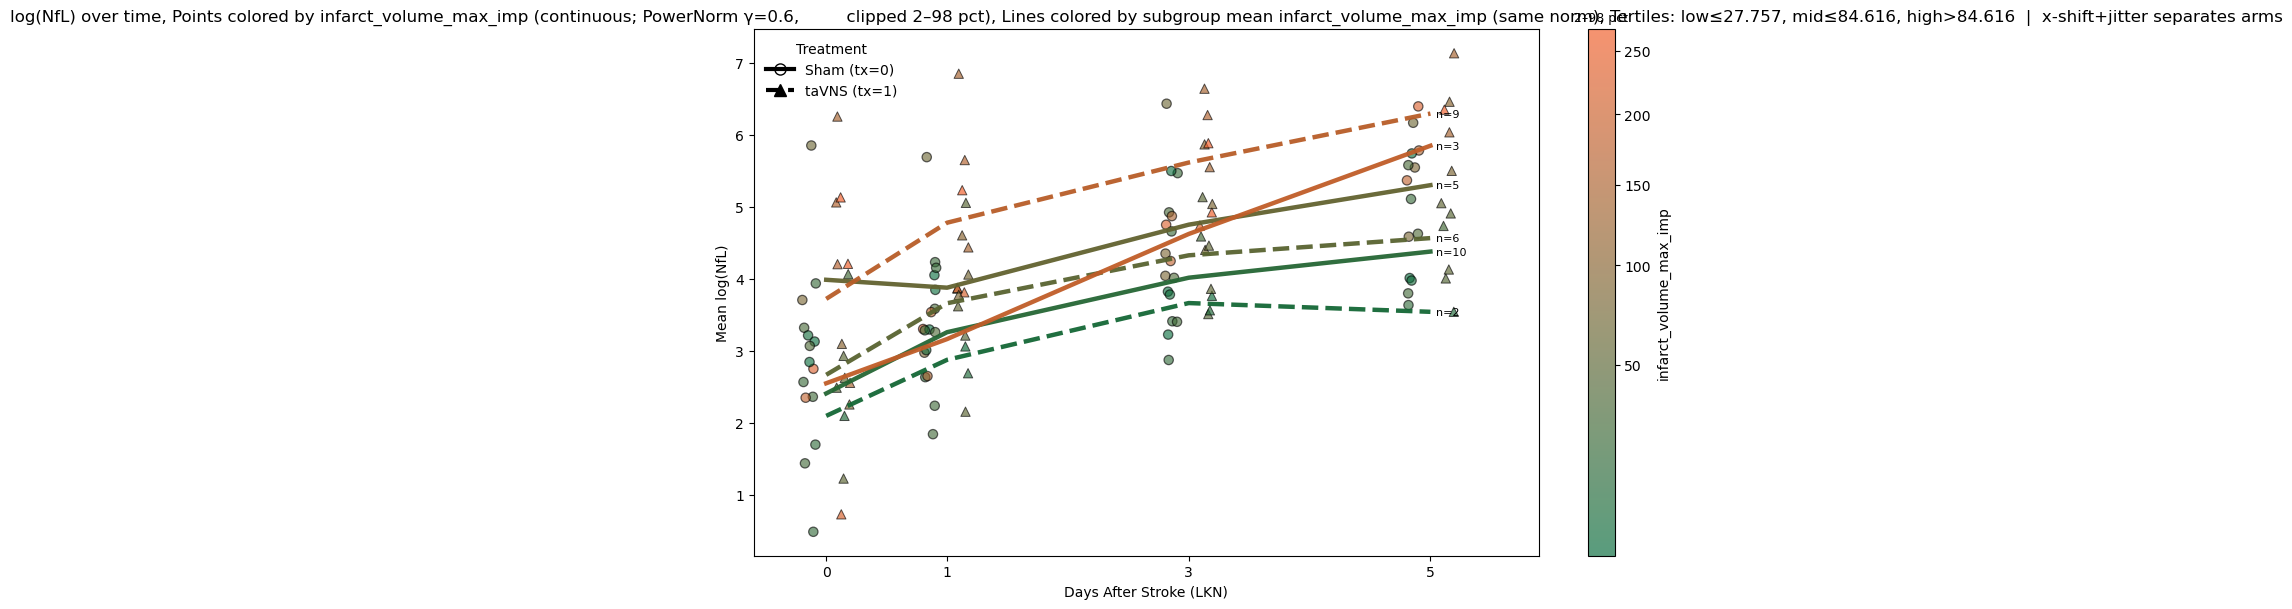

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, Normalize, PowerNorm

rng = np.random.default_rng(42)

CT_VARS_RAW = ["infarct_volume_max", "csf_ratio_min", "csf_ratio_fu24"]
CT_VARS_IMP = ["infarct_volume_max_imp", "csf_ratio_min_imp", "csf_ratio_fu24_imp", "ct_factor_1_imp"]
CT_VARS_ALL = CT_VARS_RAW + CT_VARS_IMP


def make_subject_table(df_long, id_col="personid", time_col="days_after_lkn", keep_cols=None):
    """One row per subject: take first row after sorting by time."""
    if keep_cols is None:
        raise ValueError("keep_cols must be provided")
    out = (
        df_long.sort_values([id_col, time_col])
              .groupby(id_col, as_index=False)
              .first()[keep_cols]
    )
    return out


subj_ct = make_subject_table(
    nfl_plot_data,
    keep_cols=["personid", "tx"] + [v for v in CT_VARS_ALL if v in nfl_plot_data.columns]
)

CT_VARS_ALL = [v for v in CT_VARS_ALL if v in subj_ct.columns]


def plot_balance_boxjitter(subj_df, vars_to_plot, tx_col="tx", labels=("Sham", "taVNS"),
                           ncol=4, jitter=0.08, s=25, alpha=0.6, outpath=None):
    vars_to_plot = [v for v in vars_to_plot if v in subj_df.columns]
    n = len(vars_to_plot)
    nrow = int(np.ceil(n / ncol))

    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow))
    axes = np.array(axes).reshape(-1)

    for i, v in enumerate(vars_to_plot):
        ax = axes[i]
        d0 = subj_df.loc[subj_df[tx_col] == 0, v].dropna().to_numpy()
        d1 = subj_df.loc[subj_df[tx_col] == 1, v].dropna().to_numpy()

        ax.boxplot([d0, d1], positions=[0, 1], widths=0.6, showfliers=False,
                   medianprops=dict(color="black", linewidth=2))

        j0 = 0 + rng.uniform(-jitter, jitter, size=len(d0))
        j1 = 1 + rng.uniform(-jitter, jitter, size=len(d1))
        ax.scatter(j0, d0, s=s, alpha=alpha, edgecolors="none")
        ax.scatter(j1, d1, s=s, alpha=alpha, edgecolors="none")

        ax.set_xticks([0, 1])
        ax.set_xticklabels(list(labels))
        ax.set_title(v)

    for k in range(i + 1, len(axes)):
        axes[k].axis("off")

    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, format="pdf")
    plt.show()


plot_balance_boxjitter(
    subj_ct,
    vars_to_plot=CT_VARS_ALL,
    outpath=None,
)


def add_infarct_tertiles(subj_ct, strata_var="infarct_volume_max_imp", out_col="severity_tertile"):
    q1, q2 = subj_ct[strata_var].quantile([1 / 3, 2 / 3]).to_numpy()

    def tert(v):
        if pd.isna(v):
            return np.nan
        if v <= q1:
            return "low"
        if v <= q2:
            return "mid"
        return "high"

    out = subj_ct.copy()
    out[out_col] = out[strata_var].apply(tert)
    return out, (q1, q2)


def plot_points_plus_group_lines(
    nfl_plot_data, subj_ct,
    strata_var="infarct_volume_max_imp",
    tx_col="tx", time_col="days_after_lkn", y_col="log_nfl",
    id_col="personid",
    offset=0.28, jitter=0.06,
    agg="mean",
    use_powernorm=True,
    gamma=0.6,
    clip_pct=(2, 98),
    outpath=None,
):

    cmap = LinearSegmentedColormap.from_list("infarct_cmap", ["#006837", "#f15a24"])

    subj_ct2, (q1, q2) = add_infarct_tertiles(
        subj_ct, strata_var=strata_var, out_col="severity_tertile"
    )

    tert_map = subj_ct2.set_index(id_col)["severity_tertile"]
    infarct_map = subj_ct2.set_index(id_col)[strata_var]

    df = nfl_plot_data.copy()
    df["severity_tertile"] = df[id_col].map(tert_map)
    df["infarct_for_color"] = df[id_col].map(infarct_map)

    df = df.dropna(subset=[time_col, y_col, tx_col, "severity_tertile", "infarct_for_color"]).copy()
    df[tx_col] = df[tx_col].astype(int)

    lo, hi = np.nanpercentile(df["infarct_for_color"].to_numpy(float), clip_pct)
    vals = df["infarct_for_color"].to_numpy(float)
    vals_clip = np.clip(vals, lo, hi)
    df["_infarct_color"] = vals_clip

    if use_powernorm:
        norm = PowerNorm(gamma=gamma, vmin=float(lo), vmax=float(hi))
    else:
        norm = Normalize(vmin=float(lo), vmax=float(hi))

    x_base = df[time_col].to_numpy(float)
    tx = df[tx_col].to_numpy(int)
    x_disp = (
        x_base
        + np.where(tx == 0, -offset / 2, +offset / 2)
        + rng.uniform(-jitter, jitter, size=len(x_base))
    )

    fig, ax = plt.subplots(figsize=(10.5, 6.2))

    markers = {0: "o", 1: "^"}
    face = {0: "none", 1: "full"}
    edgec = {0: "black", 1: "black"}
    lw = {0: 0.9, 1: 0.7}
    alp = {0: 0.60, 1: 0.65}

    sc = None
    for tx_val in [0, 1]:
        m = (tx == tx_val)
        sc = ax.scatter(
            x_disp[m],
            df.loc[m, y_col].to_numpy(float),
            c=df.loc[m, "_infarct_color"].to_numpy(float),
            cmap=cmap, norm=norm,
            s=45,
            marker=markers[tx_val],
            alpha=alp[tx_val],
            edgecolors=edgec[tx_val],
            linewidths=lw[tx_val],
            facecolors=("none" if face[tx_val] == "none" else None),
            zorder=2,
        )

    cb = plt.colorbar(sc, ax=ax)
    cb.set_label(strata_var)
    cb.ax.set_title(f"{clip_pct[0]}–{clip_pct[1]} pct", fontsize=9)

    if agg == "mean":
        traj = (
            df.groupby(["severity_tertile", time_col, tx_col], as_index=False)
              .agg(y=(y_col, "mean"))
        )
        ylab = "Mean log(NfL)"
    elif agg == "median":
        traj = (
            df.groupby(["severity_tertile", time_col, tx_col], as_index=False)
              .agg(y=(y_col, "median"))
        )
        ylab = "Median log(NfL)"
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    ct_grp = (
        subj_ct2.dropna(subset=["severity_tertile", strata_var, tx_col])
               .groupby(["severity_tertile", tx_col], as_index=False)
               .agg(
                   n_subjects=(id_col, "nunique"),
                   mean_infarct=(strata_var, "mean")
               )
    )

    linestyles = {0: "-", 1: "--"}

    for tert in ["low", "mid", "high"]:
        for tx_val in [0, 1]:
            sub_line = traj[(traj["severity_tertile"] == tert) & (traj[tx_col] == tx_val)]
            if sub_line.empty:
                continue

            row = ct_grp[(ct_grp["severity_tertile"] == tert) & (ct_grp[tx_col] == tx_val)]
            if row.empty:
                continue

            mean_inf = float(row["mean_infarct"].iloc[0])
            mean_inf_clip = float(np.clip(mean_inf, lo, hi))
            line_color = cmap(norm(mean_inf_clip))

            ax.plot(
                sub_line[time_col].to_numpy(float),
                sub_line["y"].to_numpy(float),
                linewidth=3.2,
                linestyle=linestyles[tx_val],
                color=line_color,
                alpha=0.95,
                zorder=5,
            )

            t_last = float(sub_line[time_col].max())
            y_last = float(sub_line.loc[sub_line[time_col] == t_last, "y"].iloc[0])
            nsub = int(row["n_subjects"].iloc[0])
            ax.text(t_last + 0.05, y_last, f"n={nsub}", fontsize=8, va="center", color="black")

    tx_handles = [
        Line2D([0], [0], marker="o", color="black", linestyle="-",
               markerfacecolor="none", markersize=8, linewidth=3, label="Sham (tx=0)"),
        Line2D([0], [0], marker="^", color="black", linestyle="--",
               markerfacecolor="black", markersize=8, linewidth=3, label="taVNS (tx=1)"),
    ]
    ax.legend(handles=tx_handles, frameon=False, loc="upper left", title="Treatment")

    days = sorted(pd.unique(df[time_col].dropna()))
    ax.set_xticks(days)
    ax.set_xlim(min(days) - 0.6, max(days) + 0.9)

    ax.set_xlabel("Days After Stroke (LKN)")
    ax.set_ylabel(ylab)
    ax.set_title(
        f"log(NfL) over time, Points colored by {strata_var} (continuous; PowerNorm γ={gamma}, \
        clipped {clip_pct[0]}–{clip_pct[1]} pct), Lines colored by subgroup mean {strata_var} (same norm), Tertiles: low≤{q1:.3f}, mid≤{q2:.3f}, high>{q2:.3f}  |  x-shift+jitter separates arms"
    )

    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, format="pdf")
    plt.show()


plot_points_plus_group_lines(
    nfl_plot_data,
    subj_ct=subj_ct,
    strata_var="infarct_volume_max_imp",
    agg="mean",
    outpath=None,
)


## effect of taVNS, tx==1

TX = 0: best a = 0.700

FINAL MODEL SUMMARY | TX = 0
Best time exponent a = 0.700
                Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      log_nfl 
No. Observations:       63           Method:                  ML      
No. Groups:             18           Scale:                   0.1917  
Min. group size:        2            Log-Likelihood:          -56.4930
Max. group size:        4            Converged:               Yes     
Mean group size:        3.5                                           
----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                    3.455    0.373  9.261 0.000  2.724  4.187
time_pow                     0.537    0.071  7.569 0.000  0.398  0.676
race_transformed            -0.791    0.344 -2.298 0.022 -1.466 -0.116
smoking_bina

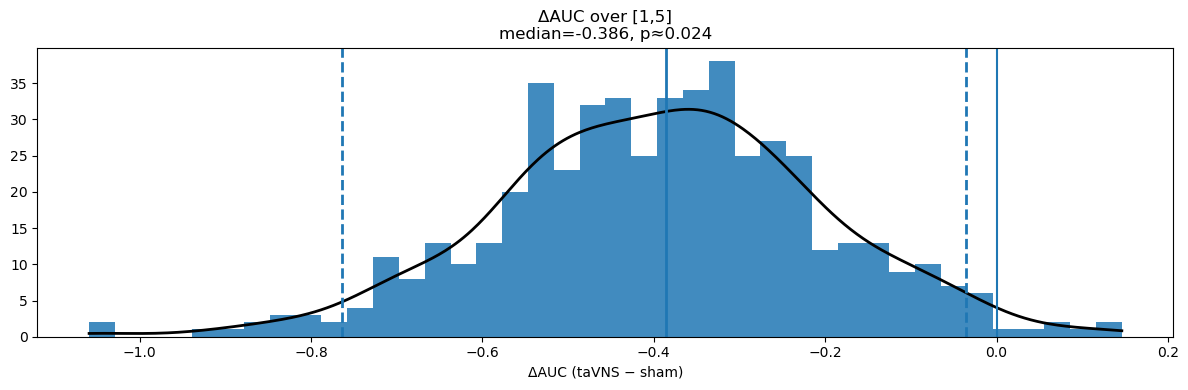

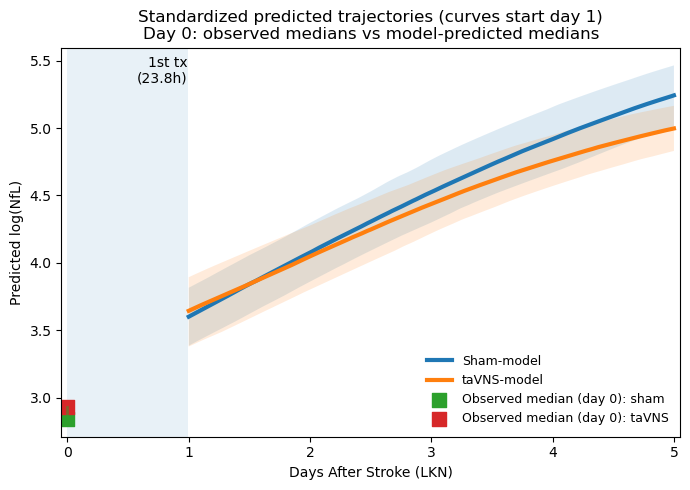

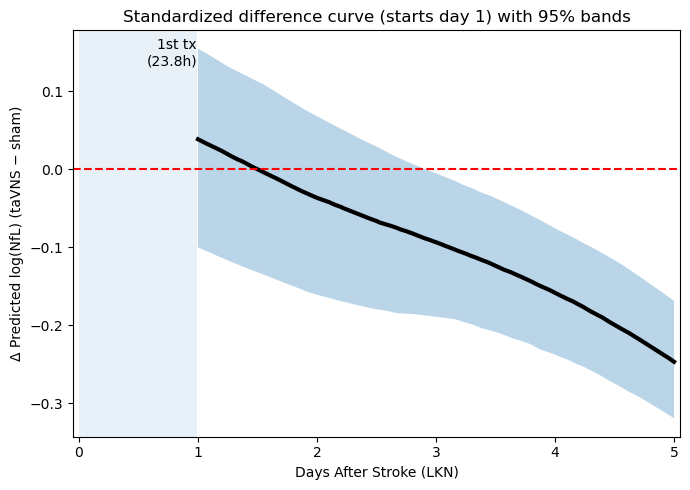

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

models_by_tx = {}

for tx_val in [0, 1]:
    df_tx = nfl_plot_data[nfl_plot_data["tx"] == tx_val].copy().reset_index(drop=True)

    best_p, best_aic_tx = None, np.inf

    for p in powers:
        df_tx["time_pow_tmp"] = df_tx["days_after_lkn"] ** p
        try:
            m_tx = smf.mixedlm(
                "log_nfl ~ time_pow_tmp + " + " + ".join(final_covariates),
                df_tx, groups=df_tx["personid"], re_formula="1"
            ).fit(method="powell", reml=False, disp=False)

            if m_tx.aic < best_aic_tx:
                best_p, best_aic_tx = float(p), m_tx.aic
        except:
            continue

    # Final refit using best exponent
    df_tx["time_pow"] = df_tx["days_after_lkn"] ** best_p
    formula_tx = "log_nfl ~ time_pow + " + " + ".join(final_covariates)

    final_tx_model = smf.mixedlm(
        formula_tx, df_tx,
        groups=df_tx["personid"], re_formula="1"
    ).fit(method="powell", reml=False, disp=False)

    models_by_tx[tx_val] = {
        "model": final_tx_model,
        "best_power": best_p
    }

    print(f"TX = {tx_val}: best a = {best_p:.3f}")
    print("\n" + "="*60)
    print(f"FINAL MODEL SUMMARY | TX = {tx_val}")
    print(f"Best time exponent a = {best_p:.3f}")
    print("="*60)
    print(final_tx_model.summary())

rng = np.random.default_rng(42)
t_tx = 23.8 / 24.0

N = 35         # matched sample
B = 500         # bootstrap draws
t_grid = np.linspace(0, 5, 201)

TX_COLORS = {0: "blue", 1: "red"}

# covariates used in your fitting pipeline (base names)
cat_vars  = ["race", "smoking_binary", "lytics"]   # add "sex" if it was in the model
cont_vars = ["ct_factor_1_imp", "baseline_il10", "delta_csf_ratio"]

covariates = cat_vars + cont_vars

USE_TRANSFORMED = True


def apply_time_transformations(df, covariates, cat_vars, cont_models, categorical_models):
    """
    Given a dataframe with base covariates and days_after_lkn, create cov_transformed columns
    using the same linear/gaussian/exclude rules
    """
    df = df.copy()
    for cov in covariates:

        # pull mode row and mode
        if cov in cat_vars:
            mode_row = categorical_models[
                (categorical_models["categorical_var"] == cov) &
                (categorical_models["response"] == "log_nfl")
            ]
            if mode_row.empty:
                mode = "linear"
            else:
                mode = mode_row["decision_mode"].values[0]
        else:
            mode_row = cont_models[
                (cont_models["predictor"] == cov) &
                (cont_models["response"] == "log_nfl")
            ]
            if mode_row.empty:
                mode = "linear"
            else:
                mode = mode_row["mode"].values[0]

        if mode == "exclude":
            continue
        out = cov + "_transformed"

        if mode == "linear":
            df[out] = df[cov]

        elif mode == "gaussian":
            mu = float(mode_row["gauss_mu"].values[0])
            sigma = float(mode_row["gauss_sigma"].values[0])
            df[out] = df[cov] * np.exp(-((df["days_after_lkn"] - mu) ** 2) / (2 * sigma ** 2))

        else:
            # fallback: treat as linear
            df[out] = df[cov]

    return df



# Categorical: empirical distribution
pop = pd.DataFrame(index=np.arange(N))
for c in cat_vars:
    vc = nfl_plot_data[c].value_counts(normalize=True, dropna=True)
    cats = vc.index.to_numpy()
    probs = vc.to_numpy()
    pop[c] = rng.choice(cats, size=N, p=probs)

mu = nfl_plot_data[cont_vars].mean().to_numpy()
S  = nfl_plot_data[cont_vars].cov().to_numpy()
S  = S + 1e-6 * np.eye(len(cont_vars))
X  = rng.multivariate_normal(mu, S, size=N)
for j, c in enumerate(cont_vars):
    pop[c] = X[:, j]

def summarize_1d(arr):
    """Median, 95% CI, and two-sided 'probability' p-value from bootstrap draws."""
    med = np.quantile(arr, 0.50)
    lo = np.quantile(arr, 0.025)
    hi = np.quantile(arr, 0.975)
    p_gt0 = np.mean(arr > 0)
    p_two = 2 * min(p_gt0, 1 - p_gt0)
    return med, lo, hi, p_gt0, p_two
def auc_trapz_interval(y, x, tmin, tmax):
    """AUC over [tmin, tmax] using trapezoid rule on subset of x in that interval."""
    mask = (x >= tmin) & (x <= tmax)
    return np.trapezoid(y[mask], x[mask])

def build_pred_df_for_model(pop_base, t_grid, p, use_transformed):
    """
    Expand pop_base across t_grid, compute time_pow, and (optionally) transformed covariates.
    Returns df_pred ready for model.predict().
    """
    df_pred = pop_base.loc[np.repeat(pop_base.index.values, len(t_grid))].copy()
    df_pred["days_after_lkn"] = np.tile(t_grid, len(pop_base))
    df_pred["time_pow"] = df_pred["days_after_lkn"] ** p

    if use_transformed:
        df_pred = apply_time_transformations(
            df_pred,
            covariates=covariates,
            cat_vars=cat_vars,
            cont_models=cont_models,
            categorical_models=categorical_models
        )

    return df_pred


pred_curves = []

for tx_val in [0, 1]:
    model = models_by_tx[tx_val]["model"]
    p = models_by_tx[tx_val]["best_power"]

    df_pred = build_pred_df_for_model(pop, t_grid, p, USE_TRANSFORMED)

    # sanity check: make sure all required exog names exist
    needed = set(model.model.exog_names) - {"Intercept"}
    missing = needed - set(df_pred.columns)
    if len(missing) > 0:
        raise ValueError(
            f"Prediction DF missing columns needed by tx={tx_val} model: {missing}\n"
            f"Model exog_names: {model.model.exog_names}"
        )

    df_pred["pred"] = model.predict(df_pred)
    df_pred["tx_model"] = tx_val

    pred_curves.append(df_pred[["days_after_lkn", "pred", "tx_model"]])

pred_curves = pd.concat(pred_curves, ignore_index=True)

mean_traj = (
    pred_curves
    .groupby(["tx_model", "days_after_lkn"], as_index=False)["pred"]
    .mean()
)

traj0 = mean_traj[mean_traj.tx_model == 0].set_index("days_after_lkn")["pred"]
traj1 = mean_traj[mean_traj.tx_model == 1].set_index("days_after_lkn")["pred"]
diff_point = (traj1 - traj0).rename("diff").reset_index()

# bootstrapping
boot0 = np.zeros((B, len(t_grid)))  # sham trajectory
boot1 = np.zeros((B, len(t_grid)))  # taVNS trajectory
bootD = np.zeros((B, len(t_grid)))  # difference

for b in range(B):
    idx = rng.integers(0, N, size=N)
    pop_b = pop.iloc[idx].reset_index(drop=True)

    preds_b = []
    for tx_val in [0, 1]:
        model = models_by_tx[tx_val]["model"]
        p = models_by_tx[tx_val]["best_power"]

        df_b = build_pred_df_for_model(pop_b, t_grid, p, USE_TRANSFORMED)

        needed = set(model.model.exog_names) - {"Intercept"}
        missing = needed - set(df_pred.columns)
        if len(missing) > 0:
            raise ValueError(
                f"Prediction DF missing columns needed by tx={tx_val} model: {missing}\n"
                f"Model exog_names: {model.model.exog_names}"
            )

        df_b["pred"] = model.predict(df_b)
        df_b["tx_model"] = tx_val
        preds_b.append(df_b[["days_after_lkn", "pred", "tx_model"]])

    preds_b = pd.concat(preds_b, ignore_index=True)
    m_b = (
        preds_b
        .groupby(["tx_model", "days_after_lkn"])["pred"]
        .mean()
        .unstack("tx_model")
    )
    
    boot0[b, :] = m_b[0].values
    boot1[b, :] = m_b[1].values
    bootD[b, :] = m_b[1].values - m_b[0].values

    # b0 = m_b.loc[0].values
    # b1 = m_b.loc[1].values
    # boot[b, :] = (b1 - b0)
def ci(arr):
    return (
        np.quantile(arr, 0.50, axis=0),
        np.quantile(arr, 0.025, axis=0),
        np.quantile(arr, 0.975, axis=0),
    )

def overlay_kde(ax, data, bins=40, color="black", lw=2):
    """Overlay a KDE scaled to histogram counts."""
    data = np.asarray(data)
    kde = gaussian_kde(data)

    x = np.linspace(data.min(), data.max(), 500)
    bin_width = (data.max() - data.min()) / bins
    y = kde(x) * len(data) * bin_width

    ax.plot(x, y, color=color, linewidth=lw)

def add_first_tx_marker(ax, t_tx, label_hours=23.8, mode="rect", alpha=0.12):
    """
    mode="rect": shade [0, t_tx]
    mode="line": vertical line at t_tx
    """
    if mode == "rect":
        ax.axvspan(0, t_tx, alpha=alpha, linewidth=0)
        ax.text(
            t_tx, 0.98, f"1st tx\n({label_hours:.1f}h)",
            transform=ax.get_xaxis_transform(),
            ha="right", va="top",
        )
    elif mode == "line":
        ax.axvline(t_tx, linestyle="--", linewidth=2)
        ax.text(
            t_tx, 0.98, f"1st tx\n({label_hours:.1f}h)",
            transform=ax.get_xaxis_transform(),
            ha="right", va="top",
        )
    
med0, lo0, hi0 = ci(boot0)
med1, lo1, hi1 = ci(boot1)
medD, loD, hiD = ci(bootD)

sel_times = np.array([1, 3, 5], dtype=float)
sel_idx = [np.argmin(np.abs(t_grid - tt)) for tt in sel_times]

# Pointwise probabilities from bootstrap difference
p_gt0 = np.mean(bootD > 0, axis=0)
p_two = 2 * np.minimum(p_gt0, 1 - p_gt0)

summary_df = pd.DataFrame({
    "day": t_grid[sel_idx],
    "median_diff": medD[sel_idx],
    "ci_lower": loD[sel_idx],
    "ci_upper": hiD[sel_idx],
    "p(diff>0)": p_gt0[sel_idx],
    "p_two_sided": p_two[sel_idx],
})

# Round to 3 decimals for reporting
summary_df = summary_df.round({
    "day": 0,
    "median_diff": 3,
    "ci_lower": 3,
    "ci_upper": 3,
    "p(diff>0)": 3,
    "p_two_sided": 3,
})

print("\n=== Pointwise Difference Summary (taVNS − Sham) ===")
print(summary_df.to_string(index=False))

# 6) AUC: 0–5 and 1–5 (per bootstrap)


auc0_15 = np.array([auc_trapz_interval(boot0[b, :], t_grid, 1, 5) for b in range(B)])
auc1_15 = np.array([auc_trapz_interval(boot1[b, :], t_grid, 1, 5) for b in range(B)])
aucD_15 = np.array([auc_trapz_interval(bootD[b, :], t_grid, 1, 5) for b in range(B)])


m0_15, l0_15, h0_15, _, _ = summarize_1d(auc0_15)
m1_15, l1_15, h1_15, _, _ = summarize_1d(auc1_15)
mD_15, lD_15, hD_15, pDgt0_15, pDtwo_15 = summarize_1d(aucD_15)


print(f"[1,5]  AUC sham  = {m0_15:.3f} [{l0_15:.3f}, {h0_15:.3f}]")
print(f"[1,5]  AUC taVNS = {m1_15:.3f} [{l1_15:.3f}, {h1_15:.3f}]")
print(f"[1,5]  ΔAUC      = {mD_15:.3f} [{lD_15:.3f}, {hD_15:.3f}] | P(ΔAUC>0)={pDgt0_15:.3f} | p≈{pDtwo_15:.3f}")

print("\nInterpretation: ΔAUC < 0 means taVNS predicts LOWER log(NfL) than sham over that interval.")

fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(aucD_15, bins=40, alpha=0.85)
overlay_kde(ax, aucD_15, bins=40)
ax.axvline(0, linewidth=1.5)
ax.axvline(lD_15, linestyle="--", linewidth=2)
ax.axvline(mD_15, linestyle="-", linewidth=2)
ax.axvline(hD_15, linestyle="--", linewidth=2)

ax.set_title(f"ΔAUC over [1,5]\nmedian={mD_15:.3f}, p≈{pDtwo_15:.3f}")
ax.set_xlabel("ΔAUC (taVNS − sham)")

plt.tight_layout()
plt.show()


i0 = int(np.argmin(np.abs(t_grid - 0.0)))
i1 = int(np.argmin(np.abs(t_grid - 1.0)))

# observed day-0 medians by arm
obs0_med = (
    nfl_plot_data.loc[nfl_plot_data["days_after_lkn"] == 0]
    .groupby("tx")["log_nfl"]
    .median()
)
obs0_sham = float(obs0_med.get(0, np.nan))
obs0_tav = float(obs0_med.get(1, np.nan))

# predicted day-0 medians from standardized curves (boot medians)
pred0_sham = float(med0[i0])
pred0_tav = float(med1[i0])

t_post = t_grid[i1:]
med0_post, lo0_post, hi0_post = med0[i1:], lo0[i1:], hi0[i1:]
med1_post, lo1_post, hi1_post = med1[i1:], lo1[i1:], hi1[i1:]

fig, ax = plt.subplots(figsize=(7, 5))

add_first_tx_marker(ax, t_tx, mode="rect", alpha=0.10)

# bands + curves starting at day 1
ax.fill_between(t_post, lo0_post, hi0_post, alpha=0.15, linewidth=0)
ax.plot(t_post, med0_post, linewidth=3, label="Sham-model")

ax.fill_between(t_post, lo1_post, hi1_post, alpha=0.15, linewidth=0)
ax.plot(t_post, med1_post, linewidth=3, label="taVNS-model")

# day-0 observed medians
if np.isfinite(obs0_sham) and np.isfinite(obs0_tav):
    ax.plot([0, 0], [obs0_sham, obs0_tav], linewidth=2, alpha=0.5)
ax.scatter([0], [obs0_sham], s=90, marker="s", label="Observed median (day 0): sham")
ax.scatter([0], [obs0_tav], s=90, marker="s", label="Observed median (day 0): taVNS")


ax.set_xlabel("Days After Stroke (LKN)")
ax.set_ylabel("Predicted log(NfL)")
ax.set_title(
    "Standardized predicted trajectories (curves start day 1)\n"
    "Day 0: observed medians vs model-predicted medians"
)
ax.set_xlim(-0.05, 5.05)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# difference plot starting day 1
medD_post, loD_post, hiD_post = medD[i1:], loD[i1:], hiD[i1:]

fig, ax = plt.subplots(figsize=(7, 5))

add_first_tx_marker(ax, t_tx, mode="rect", alpha=0.10)

ax.plot(t_post, medD_post, linewidth=3, color="black")
ax.fill_between(t_post, loD_post, hiD_post, alpha=0.30, linewidth=0)
ax.axhline(0, linestyle="--", color="red")

ax.set_xlabel("Days After Stroke (LKN)")
ax.set_ylabel("Δ Predicted log(NfL) (taVNS − sham)")
ax.set_title("Standardized difference curve (starts day 1) with 95% bands")
ax.set_xlim(-0.05, 5.05)

plt.tight_layout()
plt.show()

## control using exact samples

Empirical population size: N = 35


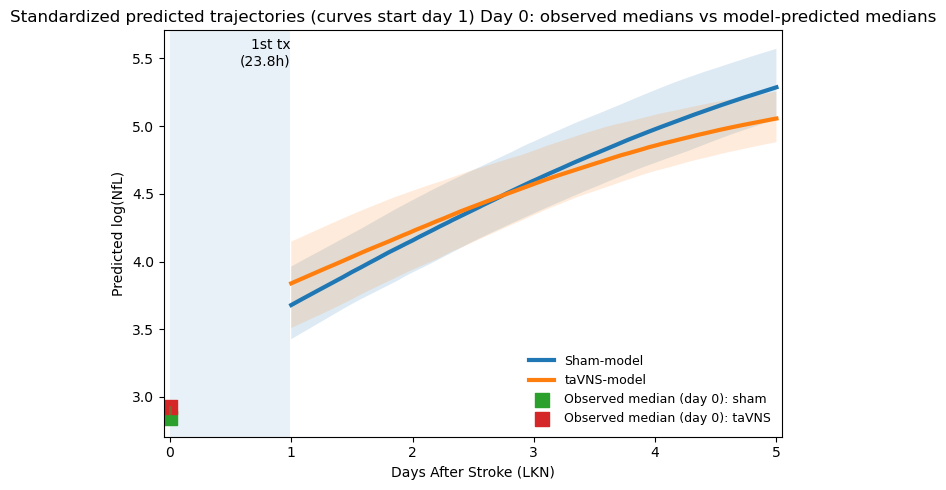

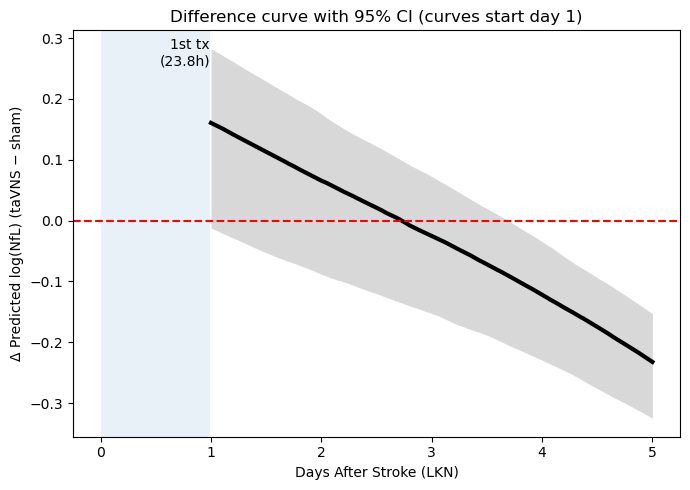


=== Pointwise Difference Summary (taVNS − Sham) ===
 day  median_diff  ci_lower  ci_upper  p(diff>0)  p_two_sided
 1.0        0.161    -0.012     0.282      0.960        0.080
 3.0       -0.025    -0.153     0.073      0.292        0.584
 5.0       -0.232    -0.325    -0.153      0.000        0.000


In [13]:
base_cols = cat_vars + cont_vars
pop = (
    nfl_plot_data
    .drop_duplicates(subset=["personid"])
    [base_cols]
    .reset_index(drop=True)
)

N = len(pop)
print(f"Empirical population size: N = {N}")

pred_curves = []

for tx_val in [0, 1]:
    model = models_by_tx[tx_val]["model"]
    p = models_by_tx[tx_val]["best_power"]

    # expand empirical population over time
    df_pred = pop.loc[np.repeat(pop.index.values, len(t_grid))].copy()
    df_pred["days_after_lkn"] = np.tile(t_grid, N)
    df_pred["time_pow"] = df_pred["days_after_lkn"] ** p

    if USE_TRANSFORMED:
        df_pred = apply_time_transformations(
            df_pred,
            covariates=covariates,
            cat_vars=cat_vars,
            cont_models=cont_models,
            categorical_models=categorical_models
        )

    needed = set(model.model.exog_names) - {"Intercept"}
    missing = needed - set(df_pred.columns)
    if missing:
        raise ValueError(f"Missing predictors for tx={tx_val}: {missing}")

    df_pred["pred"] = model.predict(df_pred)
    df_pred["tx_model"] = tx_val

    pred_curves.append(df_pred[["days_after_lkn", "pred", "tx_model"]])

pred_curves = pd.concat(pred_curves, ignore_index=True)

mean_traj = (
    pred_curves
    .groupby(["tx_model", "days_after_lkn"], as_index=False)["pred"]
    .mean()
)

traj0 = mean_traj[mean_traj.tx_model == 0].set_index("days_after_lkn")["pred"]
traj1 = mean_traj[mean_traj.tx_model == 1].set_index("days_after_lkn")["pred"]
diff_point = traj1 - traj0
B = 500
boot0 = np.zeros((B, len(t_grid)))  # sham trajectory
boot1 = np.zeros((B, len(t_grid)))  # taVNS trajectory
bootD = np.zeros((B, len(t_grid)))  # difference

for b in range(B):
    idx = rng.integers(0, N, size=N)   # resample observed rows
    pop_b = pop.iloc[idx].reset_index(drop=True)

    preds_b = []
    for tx_val in [0, 1]:
        model = models_by_tx[tx_val]["model"]
        p = models_by_tx[tx_val]["best_power"]

        df_b = pop_b.loc[np.repeat(pop_b.index.values, len(t_grid))].copy()
        df_b["days_after_lkn"] = np.tile(t_grid, len(pop_b))
        df_b["time_pow"] = df_b["days_after_lkn"] ** p

        if USE_TRANSFORMED:
            df_b = apply_time_transformations(
                df_b,
                covariates=covariates,
                cat_vars=cat_vars,
                cont_models=cont_models,
                categorical_models=categorical_models
            )

        df_b["pred"] = model.predict(df_b)
        df_b["tx_model"] = tx_val
        preds_b.append(df_b[["days_after_lkn", "pred", "tx_model"]])
    preds_b = pd.concat(preds_b, ignore_index=True)

    m_b = (
        preds_b
        .groupby(["tx_model", "days_after_lkn"])["pred"]
        .mean()
        .unstack("tx_model")
        )
    
    boot0[b, :] = m_b[0].values
    boot1[b, :] = m_b[1].values
    bootD[b, :] = m_b[1].values - m_b[0].values

def ci(arr):
    return (
        np.quantile(arr, 0.50, axis=0),
        np.quantile(arr, 0.025, axis=0),
        np.quantile(arr, 0.975, axis=0),
    )
med0, lo0, hi0 = ci(boot0)
med1, lo1, hi1 = ci(boot1)
medD, loD, hiD = ci(bootD)

fig, ax = plt.subplots(figsize=(7, 5))

add_first_tx_marker(ax, t_tx, mode="rect", alpha=0.10)

# curves start at day 1
i0 = int(np.argmin(np.abs(t_grid - 0.0)))
i1 = int(np.argmin(np.abs(t_grid - 1.0)))

t_post = t_grid[i1:]
med0_post, lo0_post, hi0_post = med0[i1:], lo0[i1:], hi0[i1:]
med1_post, lo1_post, hi1_post = med1[i1:], lo1[i1:], hi1[i1:]

# day-0 observed medians by arm
obs0_med = (
    nfl_plot_data.loc[nfl_plot_data["days_after_lkn"] == 0]
    .groupby("tx")["log_nfl"]
    .median()
)
obs0_sham = float(obs0_med.get(0, np.nan))
obs0_tav = float(obs0_med.get(1, np.nan))

ax.fill_between(t_post, lo0_post, hi0_post, alpha=0.15, linewidth=0)
ax.plot(t_post, med0_post, linewidth=3, label="Sham-model")

ax.fill_between(t_post, lo1_post, hi1_post, alpha=0.15, linewidth=0)
ax.plot(t_post, med1_post, linewidth=3, label="taVNS-model")

# day-0 observed medians
if np.isfinite(obs0_sham) and np.isfinite(obs0_tav):
    ax.plot([0, 0], [obs0_sham, obs0_tav], linewidth=2, alpha=0.5)
ax.scatter([0], [obs0_sham], s=90, marker="s", label="Observed median (day 0): sham")
ax.scatter([0], [obs0_tav], s=90, marker="s", label="Observed median (day 0): taVNS")

ax.set_xlabel("Days After Stroke (LKN)")
ax.set_ylabel("Predicted log(NfL)")
ax.set_title("Standardized predicted trajectories (curves start day 1) Day 0: observed medians vs model-predicted medians")
ax.set_xlim(-0.05, 5.05)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# difference plot starting day 1
medD_post, loD_post, hiD_post = medD[i1:], loD[i1:], hiD[i1:]

fig, ax = plt.subplots(figsize=(7, 5))

add_first_tx_marker(ax, t_tx, mode="rect", alpha=0.10)

ax.fill_between(t_post, loD_post, hiD_post, color="gray", alpha=0.30, linewidth=0)
ax.plot(t_post, medD_post, color="black", linewidth=3)
ax.axhline(0, linestyle="--", color="red")

ax.set_xlabel("Days After Stroke (LKN)")
ax.set_ylabel("Δ Predicted log(NfL) (taVNS − sham)")
ax.set_title("Difference curve with 95% CI (curves start day 1)")
plt.tight_layout()
plt.show()

sel_times = np.array([1, 3, 5], dtype=float)
sel_idx = [np.argmin(np.abs(t_grid - tt)) for tt in sel_times]

# Pointwise probabilities from bootstrap difference
p_gt0 = np.mean(bootD > 0, axis=0)
p_two = 2 * np.minimum(p_gt0, 1 - p_gt0)

summary_df = pd.DataFrame({
    "day": t_grid[sel_idx],
    "median_diff": medD[sel_idx],
    "ci_lower": loD[sel_idx],
    "ci_upper": hiD[sel_idx],
    "p(diff>0)": p_gt0[sel_idx],
    "p_two_sided": p_two[sel_idx],
})

# Round to 3 decimals for reporting
summary_df = summary_df.round({
    "day": 0,
    "median_diff": 3,
    "ci_lower": 3,
    "ci_upper": 3,
    "p(diff>0)": 3,
    "p_two_sided": 3,
})

print("\n=== Pointwise Difference Summary (taVNS − Sham) ===")
print(summary_df.to_string(index=False))
